In [1]:
import ast
import pandas as pd

ERREURS   = "../../donnees/analyse_erreurs/_analyse_erreurs__liste_des_questions_pour_les_lignes_avec_un_contexte_faux_2026-05-05T07_13_49.734048453Z.csv"
VERITE    = "../../donnees/analyse_erreurs/questions_avec_verite_terrain_tous_documents.csv"
JOINTURE  = "../../donnees/analyse_erreurs/jointure-nom-tous-documents.csv"

df_err  = pd.read_csv(ERREURS,  encoding="utf-8-sig")
df_vt   = pd.read_csv(VERITE,   encoding="utf-8-sig")
df_join = pd.read_csv(JOINTURE, encoding="utf-8-sig")

print("erreurs  :", df_err.shape,  list(df_err.columns))
print("verite   :", df_vt.shape,   list(df_vt.columns))
print("jointure :", df_join.shape, list(df_join.columns))

erreurs  : (328, 8) ['Type Question', 'Noms Documents Retournés', 'Succès Document Global', 'Succès Page Global', 'ID Expérience', 'Numéros Page Retournés', 'Réponse Générée', 'Réponse Attendue']
verite   : (1433, 11) ['REF Guide', 'REF Question', 'Question type', 'Tags', 'Tags mots clefs', 'REF Réponse', 'Réponse envisagée', 'Numéro page (lecteur)', 'Localisation paragraphe', 'Contexte', 'Indice de confiance']
jointure : (361, 6) ['REF', 'Nom', 'URL', 'Inclu ?', 'Explication RETENU', 'Fait']


In [2]:
def parse_liste(val):
    if pd.isna(val):
        return []
    try:
        return ast.literal_eval(val)
    except Exception:
        return [str(val)]

df_err["docs_retournes"]  = df_err["Noms Documents Retournés"].apply(parse_liste)
df_err["pages_retournees"] = df_err["Numéros Page Retournés"].apply(parse_liste)

df_err[["Type Question", "docs_retournes", "pages_retournees"]].head(3)

,Type Question,docs_retournes,pages_retournees
0,Quelles actions mener immédiatement en cas de ...,[CERT-FR - Recommandations à destination des a...,"[0, 77, 19, 15, 14]"
1,Quelle mesure est préconisée pour renforcer la...,[anssi-guide-passerelle_internet_securisee-v3....,"[45, 39, 51, 15, 53]"
2,Quelles mesures prendre pour se protéger contr...,"[fiches-methodes-ebios_projet.pdf, 20241212_np...","[77, 19, 64, 11, 25]"


In [3]:
df_vt_cle = df_vt[["REF Guide", "Question type", "Numéro page (lecteur)"]].copy()
df_vt_cle.columns = ["REF_guide", "question", "page_verite"]

df_join_cle = df_join[["REF", "Nom"]].copy()
df_join_cle.columns = ["REF_guide", "document_verite"]

df_vt_cle = df_vt_cle.merge(df_join_cle, on="REF_guide", how="left")

df_vt_cle.head(3)

,REF_guide,question,page_verite,document_verite
0,ANSS19,Quelles bonnes pratiques appliquer pour sécuri...,1,anssi_back to basics_hygiene_mobile_phones_1.1...
1,ANSS,Quel résultat obtient-on après application des...,2,anssi_back to basics_standalone_server_1.0.pdf
2,ANSS,Quel est le périmètre couvert par le guide de ...,1,anssi_back to basics_standalone_server_1.0.pdf


In [4]:
df_err_cle = df_err[["Type Question", "docs_retournes", "pages_retournees"]].copy()
df_err_cle.columns = ["question", "docs_retournes", "pages_retournees"]

df_final = df_err_cle.merge(df_vt_cle, on="question", how="left")

df_final = df_final[[
    "question",
    "docs_retournes",
    "pages_retournees",
    "document_verite",
    "page_verite",
]]

print(f"{len(df_final)} questions en échec")
print(f"Jointure réussie : {df_final['document_verite'].notna().sum()} / {len(df_final)}")
df_final.head(10)

328 questions en échec
Jointure réussie : 328 / 328


,question,docs_retournes,pages_retournees,document_verite,page_verite
0,Quelles actions mener immédiatement en cas de ...,[CERT-FR - Recommandations à destination des a...,"[0, 77, 19, 15, 14]",messagerie_phishing_fiche_anssi.pdf,1
1,Quelle mesure est préconisée pour renforcer la...,[anssi-guide-passerelle_internet_securisee-v3....,"[45, 39, 51, 15, 53]",messagerie_phishing_fiche_anssi.pdf,2
2,Quelles mesures prendre pour se protéger contr...,"[fiches-methodes-ebios_projet.pdf, 20241212_np...","[77, 19, 64, 11, 25]",messagerie_phishing_fiche_anssi.pdf,1
3,Quelles mesures de sécurité préventives réduis...,[20230503_anssi_mesures-cyber-preventives-prio...,"[2, 6, 6, 10, 21]",20220516_np_anssi_guide_com_crise_cyber_en.pdf,51
4,Quelles actions les équipes cyber et IT doiven...,"[anssi-guide-communication_crise_cyber.pdf, an...","[12, 37, 46, 52, 13]",20220516_np_anssi_guide_com_crise_cyber_en.pdf,38
5,Quelles règles d'administration des utilisateu...,[Fiche_methode_Systeme_dinformation _isole_et_...,"[1, 81, 6, 54, 45]",Fiche_methode_Systeme_dinformation _isole_et_s...,3
6,Quelles responsabilités incombent à l'administ...,[recommandations-sur-la-sécurisation-des-systè...,"[85, 79, 87, 78, 81]",Système de contrôle d_accès physique v1-1-fr.pdf,15
7,Quelles opérations la gestion des utilisateurs...,[Système de contrôle d_accès physique v1-1-fr....,"[5, 67, 11, 70, 12]",Système de contrôle d_accès physique v1-1-fr.pdf,20
8,Quels paramètres réseau doivent être configura...,[recommandations-sur-la-sécurisation-des-systè...,"[42, 8, 37, 29, 11]",Système de contrôle d_accès physique v1-1-fr.pdf,19
9,Quels mécanismes techniques déployer pour mett...,"[anssi-fondamentaux-zero-trust-v1.0.pdf, anssi...","[4, 8, 1, 23, 5]",anssi_back to basics_zero_trust_1.0.pdf,2


In [5]:
print("=== Questions sans correspondance dans la vérité terrain ===")
sans_vt = df_final[df_final["document_verite"].isna()]
print(f"{len(sans_vt)} questions non trouvées")
sans_vt["question"].head(10).tolist()

=== Questions sans correspondance dans la vérité terrain ===
0 questions non trouvées


[]

In [6]:
docs_erreur = (
    df_final["document_verite"]
    .value_counts()
    .rename_axis("document")
    .reset_index(name="nb_echecs")
)
print("Documents avec le plus d'échecs :")
docs_erreur.head(20)

Documents avec le plus d'échecs :


,document,nb_echecs
0,anssi-guide-organiser-un-exercice-de-gestion-d...,9
1,20150713_NP_ANSSI_SDE_firewall_mid_term_v1.0-e...,8
2,CERT-FR - Fiche réflexe - Déni de service rése...,7
3,CERT-FR - Fiche réflexe - Compromission d'un é...,7
4,20220117_np_anssi_sde_commutateur_moyen_terme_...,6
5,20220117_np_anssi_sde_pare_feu_court_terme_v1-...,6
6,anssi-guide-rules_for_secure_c_language_softwa...,4
7,high_level_risks_analysis_ai_paris_summit.pdf,4
8,anssi-guide-recommandations_securite_architect...,4
9,anssi-guide-industrial_control_systems-classif...,4


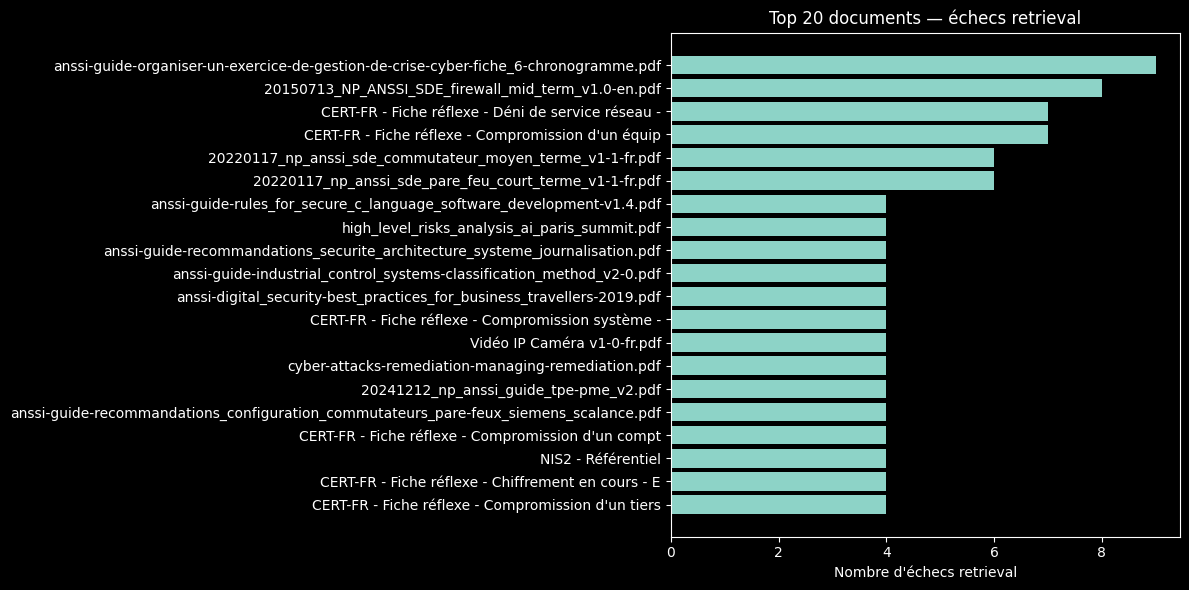

In [7]:
import matplotlib.pyplot as plt

top20 = docs_erreur.head(20)
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top20["document"][::-1], top20["nb_echecs"][::-1])
ax.set_xlabel("Nombre d'échecs retrieval")
ax.set_title("Top 20 documents — échecs retrieval")
plt.tight_layout()
plt.show()